In [1]:
!pip install -q -U biopython datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 14.3 MB/s eta 0:00:00


In [4]:
from datasets import load_dataset

ds = load_dataset("tattabio/modac_paralogy_bigene")
print(ds)

README.md:   0%|          | 0.00/370 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/996k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1492 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['ID1', 'Seq1', 'ID2', 'Seq2'],
        num_rows: 1492
    })
})


In [6]:
import pandas as pd

df = pd.DataFrame(ds["train"])

print(df.head())
print(df.columns.tolist())
print(f"Total rows: {len(df)}")

      ID1                                               Seq1     ID2  \
0  E0I7Z3  MSDTNSIIRFERVTKRYDNGSPVLSDVSFEIERGKFYTLLGPSGCG...  E0I7Z2   
1  D9PZK5  MILNAGMLSSGGVDMEYIRLEDVWKTYRTKNVTATPLRGLNMNVDK...  D9PZK6   
2  C4LAU3  MLLAEKLQTRRQGRLFEFSLQLQPGEIGLLLGRSGSGKSTLLEMLA...  C4LAU4   
3  C4LAH6  MNAIEIHNLQCGYQEQAILQNVSFVLEERKILALLGPSGCGKTTLL...  C4LAH7   
4  C4L8Q6  MHDIEIRLCWSRSEFQLDVALQLPGQGVSALFGPSGCGKTTCLRAI...  C4L8Q7   

                                                Seq2  
0  MPSRTRLRMSDKSRNWYLIPYTAWIVLFVVAPIALVVYYSLFDIEG...  
1  MRRLSSRSRAKALKALRLTVSYLVLIVMAAWSILPIYYIILISFSN...  
2  MQRRFWWCSGGLVAALILSATLGPLAALLSQPGTTTVLLWQDSYLT...  
3  MAVVRHRRWLAGSGALALLLFSPVMALLIEAFSTDAGLLQQLWQTV...  
4  MTEQDWSTVWLTLKLALLVTGILLLIATPLAWWLAQTRSRYKPLFN...  
['ID1', 'Seq1', 'ID2', 'Seq2']
Total rows: 1492


In [7]:
correct_pairs = dict(zip(df["ID1"], df["ID2"]))

print(list(correct_pairs.items())[:5])

[('E0I7Z3', 'E0I7Z2'), ('D9PZK5', 'D9PZK6'), ('C4LAU3', 'C4LAU4'), ('C4LAH6', 'C4LAH7'), ('C4L8Q6', 'C4L8Q7')]


In [8]:
def write_fasta(ids, seqs, filename):
    with open(filename, "w") as f:
        for seq_id, seq in zip(ids, seqs):
            f.write(f">{seq_id}\n{seq}\n")

# Query proteins (ModA)
write_fasta(
    df["ID1"],
    df["Seq1"],
    "modA.fasta"
)

# Database proteins (ModC)
write_fasta(
    df["ID2"],
    df["Seq2"],
    "modC.fasta"
)

print("FASTA files created successfully")

FASTA files created successfully


In [9]:
!apt-get install ncbi-blast+ -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  ncbi-data
The following NEW packages will be installed:
  ncbi-blast+ ncbi-data
0 upgraded, 2 newly installed, 0 to remove and 2 not upgraded.
Need to get 15.8 MB of archives.
After this operation, 71.8 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 ncbi-data all 6.1.20170106+dfsg1-9 [3,519 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 ncbi-blast+ amd64 2.12.0+ds-3build1 [12.3 MB]
Fetched 15.8 MB in 1s (27.4 MB/s)
Selecting previously unselected package ncbi-data.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../ncbi-data_6.1.20170106+dfsg1-9_all.deb ...
Unpacking ncbi-data (6.1.20170106+dfsg1-9) ...
Selecting previously unselected package ncbi-blast+.
Preparing to unpack .../ncbi-blast+_2.12.0+ds-3build1_amd64.deb ..

In [10]:
!makeblastdb -in modC.fasta -dbtype prot -out modC_db



Building a new DB, current time: 04/29/2026 01:18:20
New DB name:   /content/modC_db
New DB title:  modC.fasta
Sequence type: Protein
Keep MBits: T
Maximum file size: 1000000000B
Adding sequences from FASTA; added 1492 sequences in 0.032285 seconds.




In [11]:
!blastp \
-query modA.fasta \
-db modC_db \
-outfmt "6 qseqid sseqid evalue bitscore pident" \
-out blast_results.txt \
-max_target_seqs 50 \
-evalue 10

In [12]:
blast_df = pd.read_csv(
    "blast_results.txt",
    sep="\t",
    names=["query", "subject", "evalue", "bitscore", "pident"]
)

print(blast_df.head())
print(f"Total BLAST hits: {len(blast_df)}")

    query subject        evalue  bitscore  pident
0  E0I7Z3  D8FZG1  3.890000e-40     146.0  41.176
1  E0I7Z3  Q3A658  6.200000e-01      27.7  30.189
2  D9PZK5  D8FZG1  4.050000e-30     117.0  32.500
3  D9PZK5  G5F5B2  4.000000e+00      25.0  30.612
4  C4LAU3  D8FZG1  5.760000e-25      98.6  38.983
Total BLAST hits: 6186


In [13]:
def recall_at_k(blast_df, correct_pairs, k=50):
    total = 0
    correct = 0

    for query_id, group in blast_df.groupby("query"):
        if query_id not in correct_pairs:
            continue

        total += 1

        top_k = group.sort_values("evalue").head(k)

        if correct_pairs[query_id] in top_k["subject"].values:
            correct += 1

    return correct / total if total > 0 else 0

recall = recall_at_k(blast_df, correct_pairs, k=50)

print(f"BLAST Recall@50 = {recall:.4f}")

BLAST Recall@50 = 0.0027


In [15]:
print(df.head(10))
print(df.iloc[0])
print(df["ID1"].nunique())
print(df["ID2"].nunique())

      ID1                                               Seq1     ID2  \
0  E0I7Z3  MSDTNSIIRFERVTKRYDNGSPVLSDVSFEIERGKFYTLLGPSGCG...  E0I7Z2   
1  D9PZK5  MILNAGMLSSGGVDMEYIRLEDVWKTYRTKNVTATPLRGLNMNVDK...  D9PZK6   
2  C4LAU3  MLLAEKLQTRRQGRLFEFSLQLQPGEIGLLLGRSGSGKSTLLEMLA...  C4LAU4   
3  C4LAH6  MNAIEIHNLQCGYQEQAILQNVSFVLEERKILALLGPSGCGKTTLL...  C4LAH7   
4  C4L8Q6  MHDIEIRLCWSRSEFQLDVALQLPGQGVSALFGPSGCGKTTCLRAI...  C4L8Q7   
5  C4LFF5  MSSAIEIRNLTKRYNDLTILDDISFSIEPSEFIVFLGPSGCGKSTL...  C4LFF4   
6  I6ASA2  MSETRPPMIEINGVTKRFGSFTAVNRVSLQVHAGEFITLLGPSGCG...  I6ASA1   
7  I6B401  MSSSAMSATSGNETASPQPATTTPPSRAGHLQVSGVSRHFAPGAGG...  I6B402   
8  H3KAB9  MALEVAIKKYYPDFSLDVNFYTEKGILGVLGASGCGKSMTLKCIAG...  H3KAB8   
9  C1ABQ1  MSIDTNTATNTGMEGAREASNPVLDVTIRRRLPTFELDIAFRIHNG...  C1ABQ0   

                                                Seq2  
0  MPSRTRLRMSDKSRNWYLIPYTAWIVLFVVAPIALVVYYSLFDIEG...  
1  MRRLSSRSRAKALKALRLTVSYLVLIVMAAWSILPIYYIILISFSN...  
2  MQRRFWWCSGGLVAALILSATLGPLAALLSQPGTTTVLL

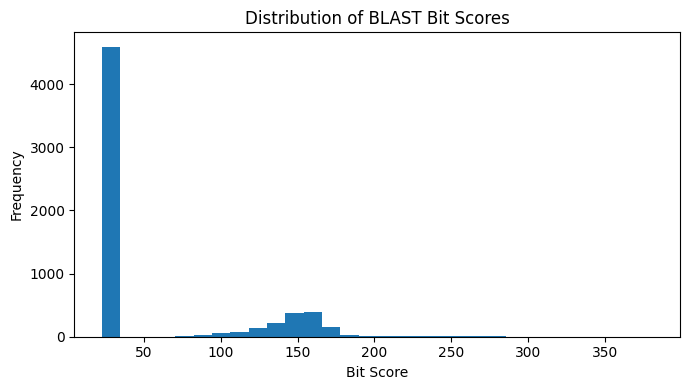

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.hist(blast_df["bitscore"], bins=30)
plt.xlabel("Bit Score")
plt.ylabel("Frequency")
plt.title("Distribution of BLAST Bit Scores")
plt.tight_layout()
plt.show()

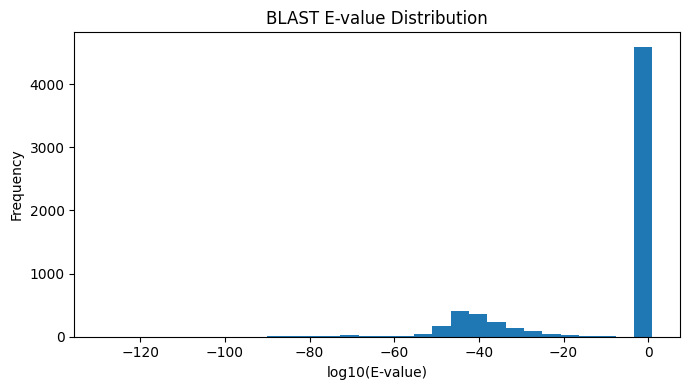

In [18]:
import numpy as np

plt.figure(figsize=(7,4))
plt.hist(np.log10(blast_df["evalue"] + 1e-200), bins=30)
plt.xlabel("log10(E-value)")
plt.ylabel("Frequency")
plt.title("BLAST E-value Distribution")
plt.tight_layout()
plt.show()